# Full State Analysis

Checking imports

In [1]:
from pathlib import Path
import numpy as np
import rasterio

state_dir = Path("/Users/evabenson/Files/thesis/snow_ml/ski_snow_states")
years_full = list(range(2000, 2024))
state_names = ['colorado', 'utah', 'wyoming', 'montana', 'idaho', 'new_mexico']

print("Checking files...")
missing = []
found   = []

for state in state_names:
    for year in years_full:
        fname = f"duration_{state}_{year}.tif"
        path  = state_dir / fname
        if path.exists():
            found.append(fname)
        else:
            missing.append(fname)
            print(f"  MISSING: {fname}")

print(f"\n{len(found)}/{len(found)+len(missing)} files found")

if not missing:
    print("\nAll files present — loading mean snow duration per state per year...")
    
    # Load mean snow duration for each state and year
    records = []
    for state in state_names:
        for year in years_full:
            path = state_dir / f"duration_{state}_{year}.tif"
            with rasterio.open(path) as src:
                arr = src.read(1).astype(float)
                arr[arr <= 0] = np.nan
                mean_dur = np.nanmean(arr)
            records.append({
                'state': state,
                'year':  year,
                'mean_snow_days': mean_dur
            })
        print(f"  {state}: loaded {len(years_full)} years")

    import pandas as pd
    snow_panel = pd.DataFrame(records)
    print(f"\nPanel dataset shape: {snow_panel.shape}")
    print(snow_panel.pivot(index='year', columns='state', values='mean_snow_days').round(1))

Checking files...

144/144 files found

All files present — loading mean snow duration per state per year...
  colorado: loaded 24 years
  utah: loaded 24 years
  wyoming: loaded 24 years
  montana: loaded 24 years
  idaho: loaded 24 years
  new_mexico: loaded 24 years

Panel dataset shape: (144, 3)
state  colorado  idaho  montana  new_mexico  utah  wyoming
year                                                      
2000       42.7   51.8     49.4        19.7  43.9     58.2
2001       38.9   48.9     36.5        12.8  36.8     44.3
2002       35.5   36.3     34.0        12.3  29.1     37.6
2003       39.5   41.5     39.0        12.4  39.9     47.3
2004       44.5   49.8     37.3        11.8  49.9     44.3
2005       37.8   50.4     41.0         5.8  35.5     45.9
2006       49.3   50.4     40.9        24.0  42.6     46.4
2007       54.5   46.9     41.2        21.8  49.8     52.9
2008       41.8   47.1     41.1        16.3  40.3     39.7
2009       49.7   49.4     45.8        26.3  49.9 

Visualizing snow data

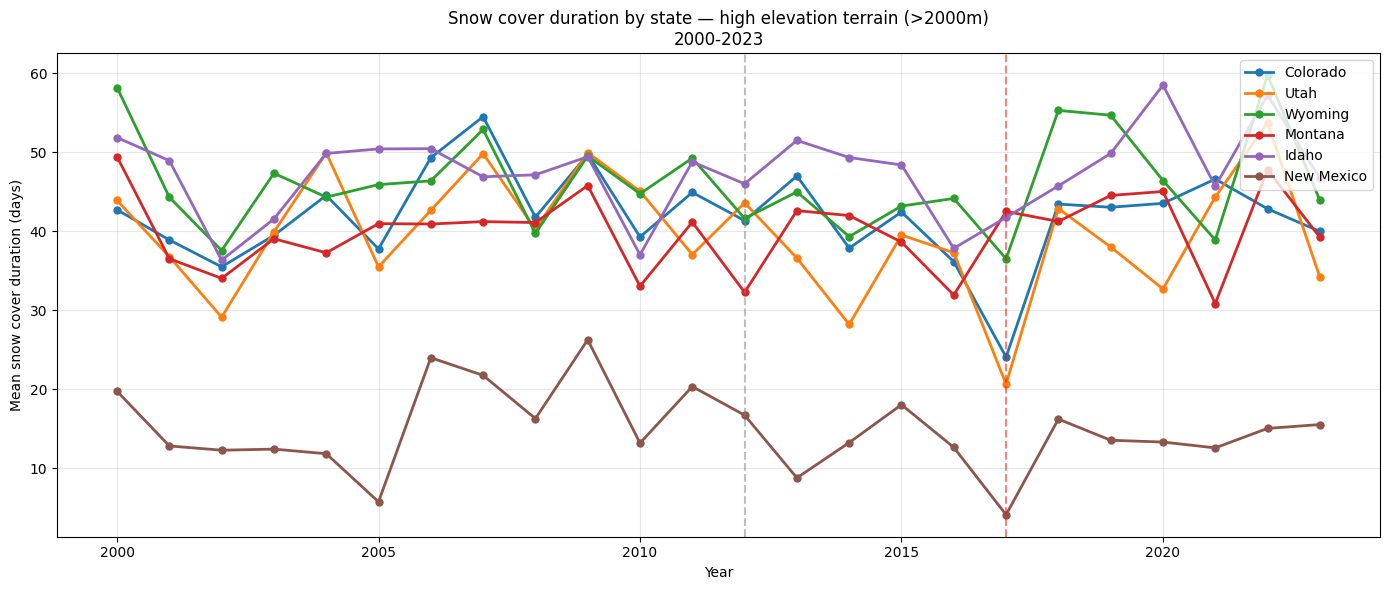

Cross-state correlations in snow cover duration:
state       colorado  idaho  montana  new_mexico   utah  wyoming
state                                                           
colorado       1.000  0.446    0.190       0.705  0.723    0.473
idaho          0.446  1.000    0.694       0.208  0.252    0.470
montana        0.190  0.694    1.000       0.229  0.067    0.624
new_mexico     0.705  0.208    0.229       1.000  0.562    0.419
utah           0.723  0.252    0.067       0.562  1.000    0.586
wyoming        0.473  0.470    0.624       0.419  0.586    1.000

Year-level summary (mean across all states):
state  all_states_mean
year                  
2000              44.3
2001              36.4
2002              30.8
2003              36.6
2004              39.6
2005              36.0
2006              42.3
2007              44.5
2008              37.7
2009              45.1
2010              35.4
2011              40.2
2012              36.9
2013              38.6
2014             

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Plot 1: Time series of snow duration by state
fig, ax = plt.subplots(figsize=(14, 6))

colors = {
    'colorado':  '#1f77b4',
    'utah':      '#ff7f0e', 
    'wyoming':   '#2ca02c',
    'montana':   '#d62728',
    'idaho':     '#9467bd',
    'new_mexico':'#8c564b'
}

for state in state_names:
    state_data = snow_panel[snow_panel['state'] == state]
    ax.plot(state_data['year'], state_data['mean_snow_days'],
            'o-', label=state.replace('_', ' ').title(),
            color=colors[state], linewidth=2, markersize=5)

ax.set_xlabel("Year")
ax.set_ylabel("Mean snow cover duration (days)")
ax.set_title("Snow cover duration by state — high elevation terrain (>2000m)\n2000-2023")
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
ax.axvline(2012, color='gray', linestyle='--', alpha=0.5, label='2012 drought')
ax.axvline(2017, color='red',  linestyle='--', alpha=0.5, label='2017 low year')
plt.tight_layout()
plt.savefig(state_dir / "snow_duration_by_state.png", dpi=150)
plt.show()

# Plot 2: Correlation between states 
pivot = snow_panel.pivot(index='year', columns='state', 
                          values='mean_snow_days')

print("Cross-state correlations in snow cover duration:")
print(pivot.corr().round(3))

# Plot 3: Year-over-year anomalies
print("\nYear-level summary (mean across all states):")
pivot['all_states_mean'] = pivot.mean(axis=1)
print(pivot[['all_states_mean']].round(1).to_string())

# Key stats 
print("\nKey statistics per state:")
print(f"{'State':<12} {'Mean':>6} {'Min':>6} {'Max':>6} {'Std':>6}")
print("-" * 36)
for state in state_names:
    d = snow_panel[snow_panel['state'] == state]['mean_snow_days']
    print(f"{state:<12} {d.mean():>6.1f} {d.min():>6.1f} "
          f"{d.max():>6.1f} {d.std():>6.1f}")

Adding ONI signals

Western snow index vs ONI:
Year    Snow days    ONI
------------------------
2000         49.2   -1.6
2001         41.1   -0.5
2002         34.5    0.7
2003         41.5    0.5
2004         45.2    0.8
2005         42.1    0.7
2006         45.9    1.0
2007         49.0   -1.4
2008         42.0   -0.7
2009         48.9    1.7
2010         39.8    1.7
2011         44.2   -1.4
2012         41.0   -0.9
2013         44.5   -0.4
2014         39.3    0.6
2015         42.4    2.4
2016         37.5   -0.6
2017         33.1   -0.9
2018         45.7    0.8
2019         46.0    0.5
2020         45.2   -1.3
2021         41.3   -1.0
2022         52.3   -0.9
2023         40.8   -0.2

Western snow index vs ONI: r = -0.103


<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

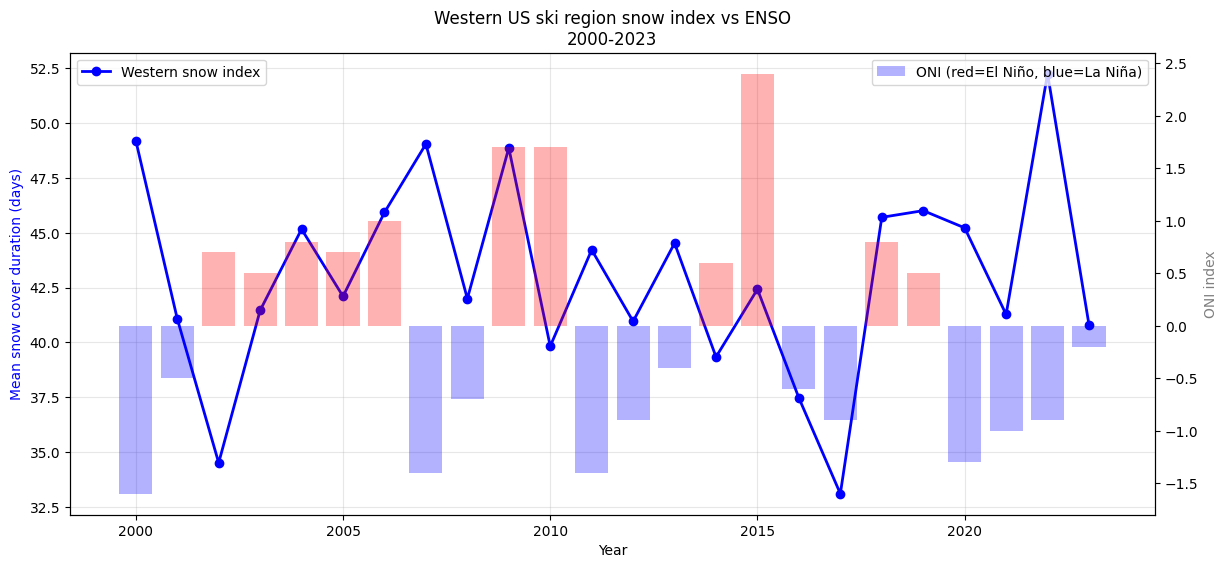

In [3]:
oni_full = {
    2000:-1.6, 2001:-0.5, 2002: 0.7, 2003: 0.5,
    2004: 0.8, 2005: 0.7, 2006: 1.0, 2007:-1.4,
    2008:-0.7, 2009: 1.7, 2010: 1.7, 2011:-1.4,
    2012:-0.9, 2013:-0.4, 2014: 0.6, 2015: 2.4,
    2016:-0.6, 2017:-0.9, 2018: 0.8, 2019: 0.5,
    2020:-1.3, 2021:-1.0, 2022:-0.9, 2023:-0.2
}

snow_panel['oni'] = snow_panel['year'].map(oni_full)

# Year-level mean (all states except New Mexico)
pivot = snow_panel.pivot(index='year', columns='state',
                          values='mean_snow_days')
pivot['western_mean'] = pivot[['colorado','utah','wyoming',
                                'montana','idaho']].mean(axis=1)
pivot['oni']          = pivot.index.map(oni_full)

print("Western snow index vs ONI:")
print(f"{'Year':<6} {'Snow days':>10} {'ONI':>6}")
print("-" * 24)
for year in years_full:
    row = pivot.loc[year]
    print(f"{year:<6} {row['western_mean']:>10.1f} {row['oni']:>6.1f}")

# Correlation of western mean with ONI
corr = pivot['western_mean'].corr(pivot['oni'])
print(f"\nWestern snow index vs ONI: r = {corr:.3f}")

# Plot snow index vs ONI
fig, ax1 = plt.subplots(figsize=(14, 6))

ax2 = ax1.twinx()
ax1.plot(pivot.index, pivot['western_mean'],
         'b-o', linewidth=2, markersize=6, label='Western snow index')
ax2.bar(pivot.index, pivot['oni'],
        alpha=0.3, color=['red' if x > 0 else 'blue' for x in pivot['oni']],
        label='ONI (red=El Niño, blue=La Niña)')

ax1.set_xlabel("Year")
ax1.set_ylabel("Mean snow cover duration (days)", color='blue')
ax2.set_ylabel("ONI index", color='gray')
ax1.set_title("Western US ski region snow index vs ENSO\n2000-2023")
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

plt.tight_layout

Adding Satellite Account Winter Recreation GDP Value Added Data

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

gdp_dir  = Path("/Users/evabenson/Files/thesis/snow_ml/gdp_data")
state_dir = Path("/Users/evabenson/Files/thesis/snow_ml/ski_snow_states")

# Load outdoor recreation GDP
gdp_raw = pd.read_csv(gdp_dir / "outdoor_rec.csv", skiprows=3)
gdp_raw = gdp_raw[pd.to_numeric(gdp_raw['GeoFIPS'], errors='coerce').notna()]
print("Raw GDP data:")
print(gdp_raw)

gdp_long = gdp_raw.melt(
    id_vars=['GeoFIPS', 'GeoName'],
    var_name='year',
    value_name='outdoor_rec_gdp'
)

gdp_long['year']            = gdp_long['year'].astype(int)
gdp_long['outdoor_rec_gdp'] = pd.to_numeric(gdp_long['outdoor_rec_gdp'],
                                              errors='coerce')

gdp_long['outdoor_rec_gdp_millions'] = gdp_long['outdoor_rec_gdp'] / 1000

state_map = {
    'Colorado':   'colorado',
    'Idaho':      'idaho',
    'Montana':    'montana',
    'New Mexico': 'new_mexico',
    'Utah':       'utah',
    'Wyoming':    'wyoming'
}
gdp_long['state'] = gdp_long['GeoName'].map(state_map)

print("\nGDP long format:")
print(gdp_long[['state','year','outdoor_rec_gdp_millions']].head(12))

panel = snow_panel.merge(
    gdp_long[['state','year','outdoor_rec_gdp_millions']],
    on=['state','year'],
    how='inner'
)

print(f"\nMerged panel shape: {panel.shape}")
print(f"Years covered: {panel['year'].min()} - {panel['year'].max()}")
print(f"States: {panel['state'].unique()}")
print(f"\nPanel preview:")
print(panel.pivot(index='year', columns='state',
                  values='outdoor_rec_gdp_millions').round(1))

Raw GDP data:
  GeoFIPS     GeoName      2012      2013       2014       2015       2016  \
0   08000    Colorado  772870.0  848508.0  1023835.0  1148105.0  1193478.0   
1   16000       Idaho   46782.0   49952.0    58364.0    63527.0    70310.0   
2   30000     Montana   31741.0   28647.0    34216.0    34957.0    37638.0   
3   35000  New Mexico   37496.0   39206.0    45473.0    49782.0    55615.0   
4   49000        Utah  238513.0  250415.0   288358.0   312302.0   350151.0   
5   56000     Wyoming   14731.0   15060.0    17409.0    18282.0    19458.0   

        2017       2018       2019      2020      2021       2022       2023  \
0  1195056.0  1225802.0  1229744.0  853936.0  988257.0  1433813.0  1562853.0   
1    78356.0    86831.0    95509.0   75729.0   87555.0   122267.0   140072.0   
2    41229.0    43274.0    47030.0   42554.0   53564.0    75386.0    82346.0   
3    62829.0    67433.0    75055.0   55082.0   63820.0    87987.0    97425.0   
4   387799.0   423757.0   453739.0  341

Running the Regression

Model 1: Snow only (no fixed effects)
  β_snow:    0.0062
  R²:        0.004
  Interpret: +1 snow day → 0.62% change in outdoor rec GDP

Model 2: Snow + state fixed effects
  β_snow:    0.0086
  R²:        0.952
  Interpret: +1 snow day → 0.86% change in outdoor rec GDP

Model 3: Snow + state FE + year FE (preferred)
  β_snow:    -0.0020
  R²:        0.996
  Interpret: +1 snow day → -0.20% change in outdoor rec GDP

  Mean outdoor rec GDP: $286.7M
  +1 snow day → $-0.6M change in outdoor rec GDP
  Across 6 states, 1 additional snow day ≈ $-3.5M total


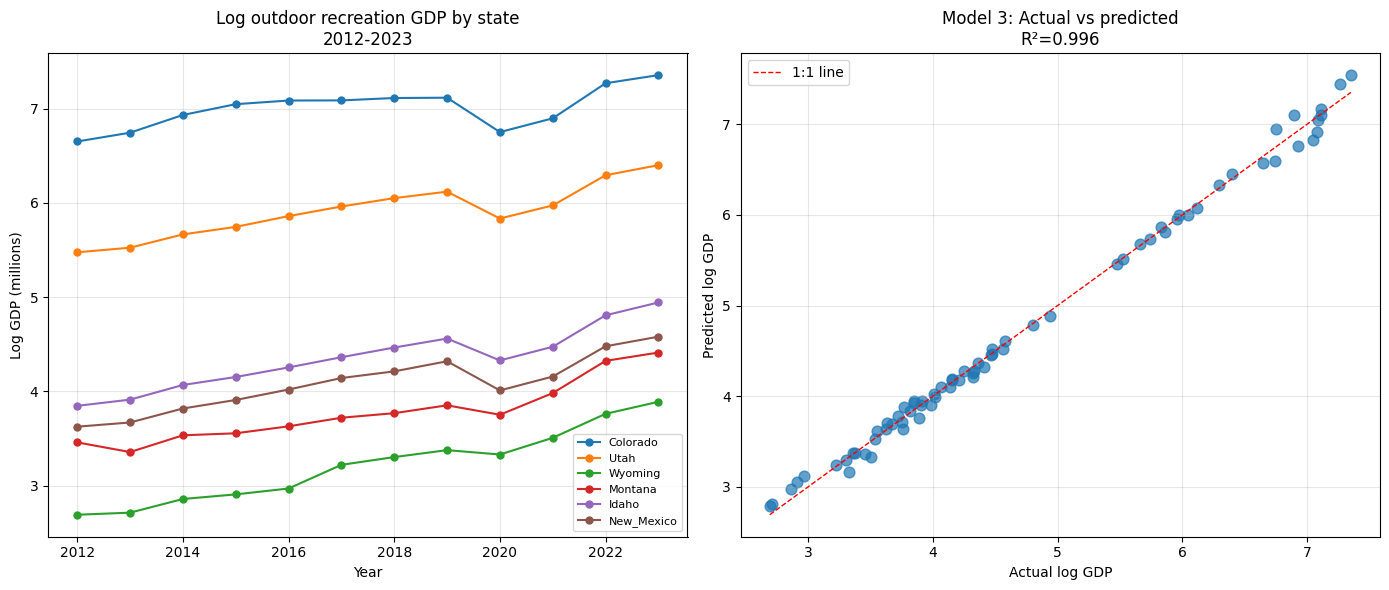

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np
import matplotlib.pyplot as plt

# Add log GDP 
panel['log_gdp'] = np.log(panel['outdoor_rec_gdp_millions'])

# Create fixed effects dummies
state_dummies = pd.get_dummies(panel['state'], prefix='state', drop_first=True)
year_dummies  = pd.get_dummies(panel['year'],  prefix='year',  drop_first=True)

# Model 1: Snow only (no fixed effects)
X1 = panel[['mean_snow_days']].values
y  = panel['log_gdp'].values

lr1 = LinearRegression().fit(X1, y)
print("Model 1: Snow only (no fixed effects)")
print(f"  β_snow:    {lr1.coef_[0]:.4f}")
print(f"  R²:        {r2_score(y, lr1.predict(X1)):.3f}")
print(f"  Interpret: +1 snow day → {lr1.coef_[0]*100:.2f}% change in outdoor rec GDP")

# Model 2: Snow + state fixed effects
X2 = pd.concat([panel[['mean_snow_days']], state_dummies], axis=1).values

lr2 = LinearRegression().fit(X2, y)
print("\nModel 2: Snow + state fixed effects")
print(f"  β_snow:    {lr2.coef_[0]:.4f}")
print(f"  R²:        {r2_score(y, lr2.predict(X2)):.3f}")
print(f"  Interpret: +1 snow day → {lr2.coef_[0]*100:.2f}% change in outdoor rec GDP")

# Model 3: Snow + state + year fixed effects 
X3 = pd.concat([panel[['mean_snow_days']],
                state_dummies, year_dummies], axis=1).values

lr3 = LinearRegression().fit(X3, y)
print("\nModel 3: Snow + state FE + year FE (preferred)")
print(f"  β_snow:    {lr3.coef_[0]:.4f}")
print(f"  R²:        {r2_score(y, lr3.predict(X3)):.3f}")
print(f"  Interpret: +1 snow day → {lr3.coef_[0]*100:.2f}% change in outdoor rec GDP")

mean_gdp = panel['outdoor_rec_gdp_millions'].mean()
dollar_impact = lr3.coef_[0] * mean_gdp
print(f"\n  Mean outdoor rec GDP: ${mean_gdp:.1f}M")
print(f"  +1 snow day → ${dollar_impact:.1f}M change in outdoor rec GDP")
print(f"  Across 6 states, 1 additional snow day ≈ ${dollar_impact*6:.1f}M total")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

y_pred3 = lr3.predict(X3)

for state in state_names:
    mask = panel['state'] == state
    axes[0].plot(panel[mask]['year'],
                 panel[mask]['log_gdp'],
                 'o-', label=state.title(), markersize=5)
axes[0].set_title("Log outdoor recreation GDP by state\n2012-2023")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Log GDP (millions)")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Actual vs predicted
axes[1].scatter(y, y_pred3, alpha=0.7, s=60)
axes[1].plot([y.min(), y.max()], [y.min(), y.max()],
             'r--', linewidth=1, label='1:1 line')
axes[1].set_xlabel("Actual log GDP")
axes[1].set_ylabel("Predicted log GDP")
axes[1].set_title(f"Model 3: Actual vs predicted\nR²={r2_score(y, y_pred3):.3f}")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(state_dir / "gdp_regression.png", dpi=150)
plt.show()

Demeaned snow variable (removes state size differences):
           snow_demeaned                                           
                   count mean   std    min   25%   50%   75%    max
state                                                              
colorado            12.0  0.0  6.09 -16.60 -1.24  1.94  2.77   6.30
idaho               12.0 -0.0  5.80 -10.37 -2.48 -0.66  2.05  10.28
montana             12.0 -0.0  5.52  -9.03 -2.85  1.73  3.20   7.91
new_mexico          12.0  0.0  3.77  -9.20 -0.69  0.12  2.39   4.73
utah                12.0 -0.0  8.45 -16.98 -3.83  0.01  5.41  16.08
wyoming             12.0 -0.0  7.20  -9.21 -4.69 -1.69  2.76  14.03

Within-state fixed effects regression:
  β_snow (demeaned):  0.0086
  R² (within):        0.030
  Interpret: when a state gets +1 snow day above its own average,
  outdoor rec GDP changes by 0.86%

  Mean GDP: $286.7M
  +1 snow day above average → $2.5M change in GDP


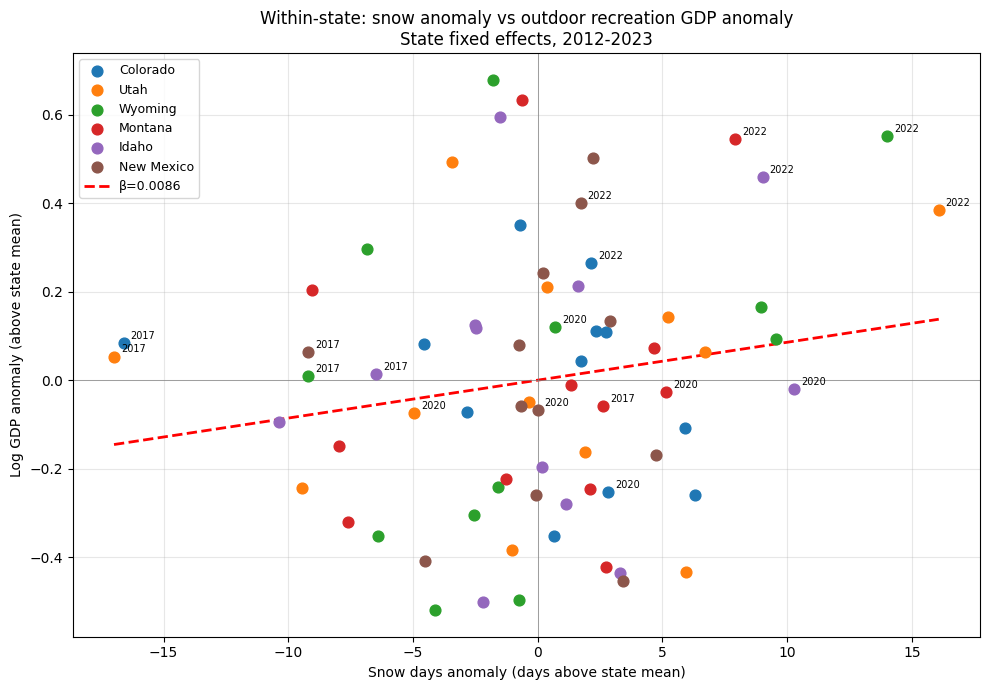

In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np

panel['snow_demeaned'] = panel.groupby('state')['mean_snow_days'].transform(
    lambda x: x - x.mean()
)
panel['gdp_demeaned']  = panel.groupby('state')['log_gdp'].transform(
    lambda x: x - x.mean()
)

print("Demeaned snow variable (removes state size differences):")
print(panel.groupby('state')[['snow_demeaned']].describe().round(2))

# Within-state regression
X_fe = panel['snow_demeaned'].values.reshape(-1, 1)
y_fe = panel['gdp_demeaned'].values

lr_fe = LinearRegression().fit(X_fe, y_fe)

print(f"\nWithin-state fixed effects regression:")
print(f"  β_snow (demeaned):  {lr_fe.coef_[0]:.4f}")
print(f"  R² (within):        {r2_score(y_fe, lr_fe.predict(X_fe)):.3f}")
print(f"  Interpret: when a state gets +1 snow day above its own average,")
print(f"  outdoor rec GDP changes by {lr_fe.coef_[0]*100:.2f}%")

mean_gdp = panel['outdoor_rec_gdp_millions'].mean()
dollar   = lr_fe.coef_[0] * mean_gdp
print(f"\n  Mean GDP: ${mean_gdp:.1f}M")
print(f"  +1 snow day above average → ${dollar:.1f}M change in GDP")

fig, ax = plt.subplots(figsize=(10, 7))

colors_map = {
    'colorado':'#1f77b4', 'utah':'#ff7f0e', 'wyoming':'#2ca02c',
    'montana':'#d62728',  'idaho':'#9467bd', 'new_mexico':'#8c564b'
}

for state in state_names:
    mask = panel['state'] == state
    ax.scatter(panel[mask]['snow_demeaned'],
               panel[mask]['gdp_demeaned'],
               label=state.replace('_',' ').title(),
               color=colors_map[state], s=60, zorder=3)

    for yr in [2017, 2020, 2022]:
        row = panel[mask & (panel['year'] == yr)]
        if not row.empty:
            ax.annotate(str(yr),
                       (row['snow_demeaned'].values[0],
                        row['gdp_demeaned'].values[0]),
                       textcoords="offset points",
                       xytext=(5,3), fontsize=7)

x_line = np.linspace(panel['snow_demeaned'].min(),
                     panel['snow_demeaned'].max(), 100)
ax.plot(x_line, lr_fe.coef_[0]*x_line + lr_fe.intercept_,
        'r--', linewidth=2, label=f'β={lr_fe.coef_[0]:.4f}')

ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlabel("Snow days anomaly (days above state mean)")
ax.set_ylabel("Log GDP anomaly (above state mean)")
ax.set_title("Within-state: snow anomaly vs outdoor recreation GDP anomaly\n"
             "State fixed effects, 2012-2023")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(state_dir / "within_state_regression.png", dpi=150)
plt.show()

Snow Trend Model

Snow cover duration trend (2000-2023):
  Slope:     0.006 days/year
  R²:        0.000
  p-value:   0.965
  Total trend 2000-2023: 0.1 days
  No statistically significant trend detected

Projected snow duration:
  2030: 43.1 days (range: 34.4 - 51.9)
  2040: 43.2 days (range: 34.4 - 51.9)
  2050: 43.3 days (range: 34.5 - 52.0)


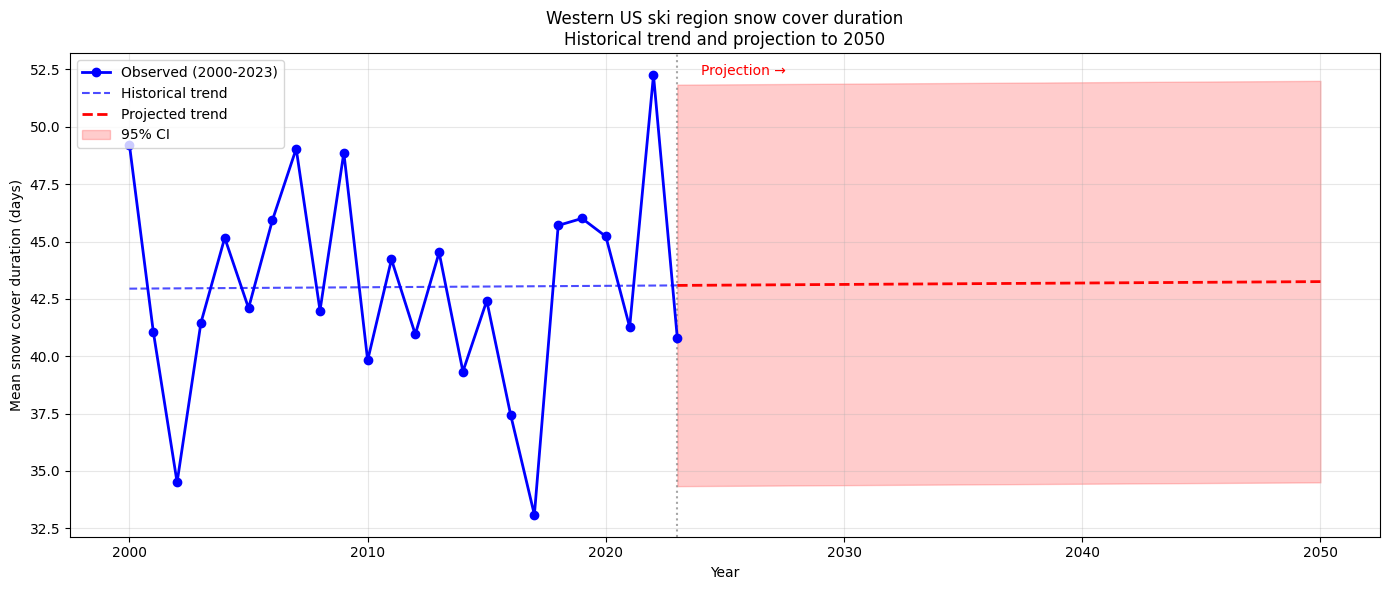

In [ ]:
from sklearn.linear_model import LinearRegression
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

# Compute western mean snow index
pivot = snow_panel.pivot(index='year', columns='state',
                          values='mean_snow_days')
# Exclude New Mexico — outlier
pivot['western_mean'] = pivot[['colorado','utah','wyoming',
                                'montana','idaho']].mean(axis=1)

years_arr  = pivot.index.values.reshape(-1, 1)
snow_arr   = pivot['western_mean'].values

lr_trend = LinearRegression().fit(years_arr, snow_arr)
slope     = lr_trend.coef_[0]
intercept = lr_trend.intercept_

slope_stat, intercept_stat, r, p, se = stats.linregress(
    pivot.index.values, snow_arr
)

print("Snow cover duration trend (2000-2023):")
print(f"  Slope:     {slope:.3f} days/year")
print(f"  R²:        {r**2:.3f}")
print(f"  p-value:   {p:.3f}")
print(f"  Total trend 2000-2023: {slope*23:.1f} days")

if p < 0.05:
    print("  *** Statistically significant trend ***")
elif p < 0.10:
    print("  * Marginally significant trend (p<0.10)")
else:
    print("  No statistically significant trend detected")

# Project to 2050
future_years = np.arange(2000, 2051)
snow_projected = lr_trend.predict(future_years.reshape(-1, 1))

n    = len(pivot)
se_snow = np.std(snow_arr - lr_trend.predict(years_arr))
ci   = 1.96 * se_snow

print(f"\nProjected snow duration:")
for yr in [2030, 2040, 2050]:
    proj = lr_trend.predict([[yr]])[0]
    print(f"  {yr}: {proj:.1f} days "
          f"(range: {proj-ci:.1f} - {proj+ci:.1f})")

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(pivot.index, snow_arr, 'bo-', linewidth=2,
        markersize=6, label='Observed (2000-2023)', zorder=3)

hist_years = np.arange(2000, 2024)
ax.plot(hist_years,
        lr_trend.predict(hist_years.reshape(-1,1)),
        'b--', linewidth=1.5, alpha=0.7, label='Historical trend')

proj_years = np.arange(2023, 2051)
proj_vals  = lr_trend.predict(proj_years.reshape(-1,1))
ax.plot(proj_years, proj_vals, 'r--', linewidth=2,
        label='Projected trend')
ax.fill_between(proj_years,
                proj_vals - ci,
                proj_vals + ci,
                alpha=0.2, color='red', label='95% CI')

ax.axvline(2023, color='gray', linestyle=':', alpha=0.7)
ax.text(2024, snow_arr.max(), 'Projection →', fontsize=10, color='red')
ax.set_xlabel("Year")
ax.set_ylabel("Mean snow cover duration (days)")
ax.set_title("Western US ski region snow cover duration\nHistorical trend and projection to 2050")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(state_dir / "snow_trend_projection.png", dpi=150)
plt.show()

Snow cover duration --> Outdoor recreation GDP

  β (snow days):  0.0086
  R²:             0.030
  p-value:        0.146
  Std error:      0.0058
  Not statistically significant

  Mean outdoor rec GDP per state: $286.7M
  +1 snow day → +0.86% GDP per state
  +1 snow day → +$2.5M per state
  +1 snow day → +$12.3M across 5 states

Scenario                               Per state     5 states
------------------------------------------------------------
  Average year (baseline)           $     +0.0M $     +0.0M
  Good year (+5 snow days)          $    +12.3M $    +61.3M
  Great year (+10 snow days)        $    +24.5M $   +122.7M
  Poor year (-5 snow days)          $    -12.3M $    -61.3M
  Bad year like 2017 (-10d)         $    -24.5M $   -122.7M

Climate warming scenarios (using β_tmin = -2.97 days/°C):
Warming          Snow change  GDP impact (5 states)
--------------------------------------------------
  +1°C                -3.0d   $          -36.4M
  +2°C                -5.9d   $    

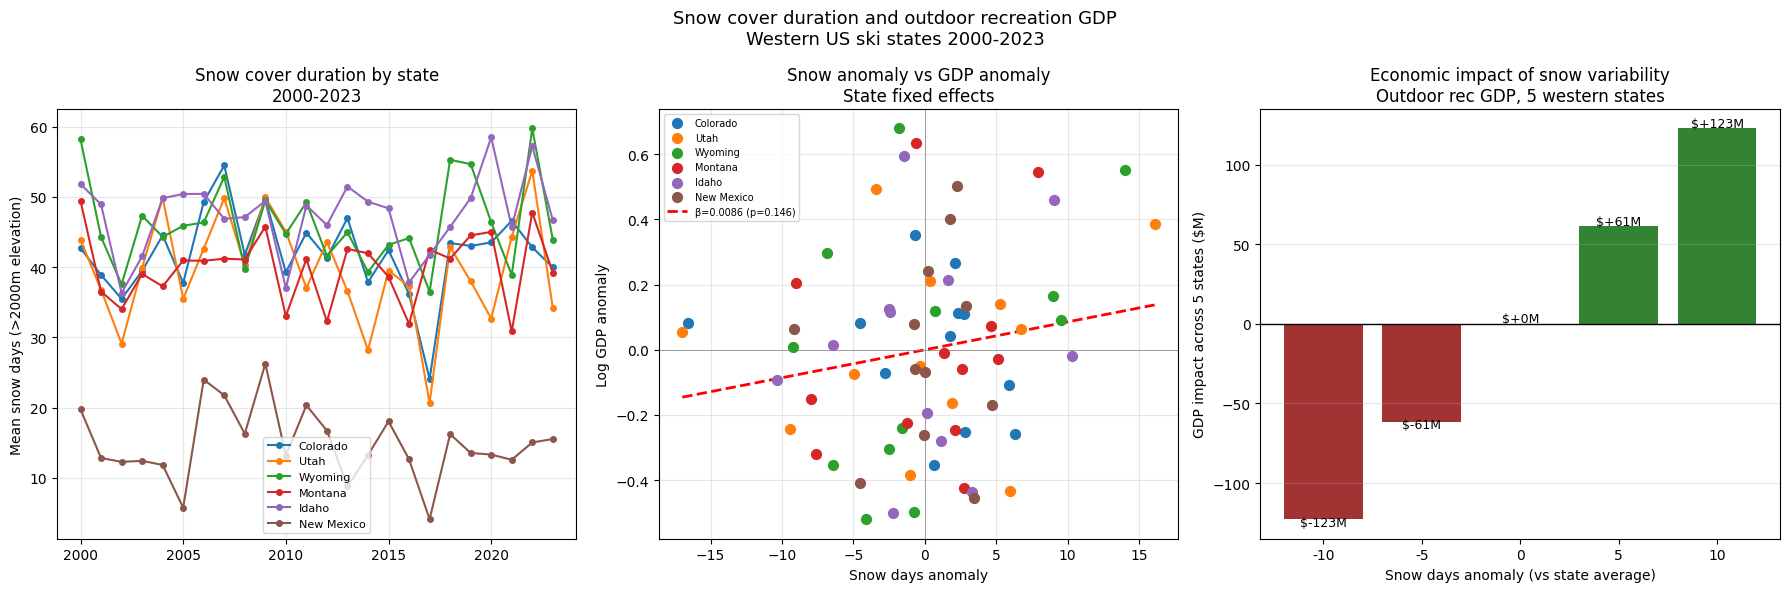

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from scipy import stats

# SNOW COVER --> OUTDOOR RECREATION GDP

panel['snow_demeaned'] = panel.groupby('state')['mean_snow_days'].transform(
    lambda x: x - x.mean()
)
panel['gdp_demeaned'] = panel.groupby('state')['log_gdp'].transform(
    lambda x: x - x.mean()
)

X = panel['snow_demeaned'].values
y = panel['gdp_demeaned'].values

slope, intercept, r, p, se = stats.linregress(X, y)

print("Snow cover duration --> Outdoor recreation GDP")
print(f"\n  β (snow days):  {slope:.4f}")
print(f"  R²:             {r**2:.3f}")
print(f"  p-value:        {p:.3f}")
print(f"  Std error:      {se:.4f}")

if p < 0.05:
    print("  *** Statistically significant at 5% level ***")
elif p < 0.10:
    print("  * Significant at 10% level")
else:
    print("  Not statistically significant")

mean_gdp = panel['outdoor_rec_gdp_millions'].mean()
dollar_per_day_per_state = slope * mean_gdp
dollar_per_day_all_states = dollar_per_day_per_state * 5

print(f"\n  Mean outdoor rec GDP per state: ${mean_gdp:.1f}M")
print(f"  +1 snow day → +{slope*100:.2f}% GDP per state")
print(f"  +1 snow day → +${dollar_per_day_per_state:.1f}M per state")
print(f"  +1 snow day → +${dollar_per_day_all_states:.1f}M across 5 states")

print(f"\n{'Scenario':<35} {'Per state':>12} {'5 states':>12}")
print("-" * 60)

scenarios = [
    ("Average year (baseline)",      0),
    ("Good year (+5 snow days)",     5),
    ("Great year (+10 snow days)",  10),
    ("Poor year (-5 snow days)",    -5),
    ("Bad year like 2017 (-10d)", -10),
]

for label, delta in scenarios:
    per_state = slope * delta * mean_gdp
    total     = per_state * 5
    print(f"  {label:<33} ${per_state:>+9.1f}M ${total:>+9.1f}M")

print(f"\nClimate warming scenarios (using β_tmin = -2.97 days/°C):")
print(f"{'Warming':<15} {'Snow change':>12} {'GDP impact (5 states)':>22}")
print("-" * 50)

beta_tmin = -2.97
for warming in [1.0, 2.0, 3.0, 4.0]:
    snow_chg = beta_tmin * warming
    gdp_chg  = slope * snow_chg * mean_gdp * 5
    print(f"  +{warming:.0f}°C          {snow_chg:>+10.1f}d "
          f"  ${gdp_chg:>+15.1f}M")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors_map = {
    'colorado':'#1f77b4', 'utah':'#ff7f0e', 'wyoming':'#2ca02c',
    'montana':'#d62728',  'idaho':'#9467bd', 'new_mexico':'#8c564b'
}
for state in state_names:
    d = snow_panel[snow_panel['state']==state]
    axes[0].plot(d['year'], d['mean_snow_days'],
                 'o-', label=state.replace('_',' ').title(),
                 color=colors_map[state], linewidth=1.5, markersize=4)
axes[0].set_title("Snow cover duration by state\n2000-2023")
axes[0].set_ylabel("Mean snow days (>2000m elevation)")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

for state in state_names:
    mask = panel['state'] == state
    axes[1].scatter(panel[mask]['snow_demeaned'],
                    panel[mask]['gdp_demeaned'],
                    label=state.replace('_',' ').title(),
                    color=colors_map[state], s=50, zorder=3)

x_line = np.linspace(X.min(), X.max(), 100)
axes[1].plot(x_line, slope*x_line + intercept,
             'r--', linewidth=2, label=f'β={slope:.4f} (p={p:.3f})')
axes[1].axhline(0, color='gray', linewidth=0.5)
axes[1].axvline(0, color='gray', linewidth=0.5)
axes[1].set_xlabel("Snow days anomaly")
axes[1].set_ylabel("Log GDP anomaly")
axes[1].set_title("Snow anomaly vs GDP anomaly\nState fixed effects")
axes[1].legend(fontsize=7)
axes[1].grid(True, alpha=0.3)

delta_snows = [-10, -5, 0, 5, 10]
gdp_impacts = [slope * d * mean_gdp * 5 for d in delta_snows]
bar_colors  = ['darkred' if x < 0 else 'darkgreen' if x > 0
               else 'gray' for x in gdp_impacts]

bars = axes[2].bar([str(d) for d in delta_snows],
                   gdp_impacts, color=bar_colors, alpha=0.8)
axes[2].axhline(0, color='black', linewidth=1)
axes[2].set_xlabel("Snow days anomaly (vs state average)")
axes[2].set_ylabel("GDP impact across 5 states ($M)")
axes[2].set_title("Economic impact of snow variability\nOutdoor rec GDP, 5 western states")
axes[2].grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, gdp_impacts):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + (1 if val >= 0 else -4),
                 f'${val:+.0f}M', ha='center', fontsize=9)

plt.suptitle("Snow cover duration and outdoor recreation GDP\n"
             "Western US ski states 2000-2023", fontsize=13)
plt.tight_layout()
plt.savefig(state_dir / "final_results.png", dpi=150)
plt.show()

In [ ]:
# Drop New Mexico (low snow, different climate) 
panel_clean = panel[
    (panel['state'] != 'new_mexico') &
    (panel['year'] != 2020)
].copy()

panel_clean['snow_demeaned'] = panel_clean.groupby('state')['mean_snow_days'].transform(
    lambda x: x - x.mean()
)
panel_clean['gdp_demeaned'] = panel_clean.groupby('state')['log_gdp'].transform(
    lambda x: x - x.mean()
)

X_clean = panel_clean['snow_demeaned'].values
y_clean = panel_clean['gdp_demeaned'].values

slope_c, intercept_c, r_c, p_c, se_c = stats.linregress(X_clean, y_clean)

print("Clean sample (no NM, no 2020):")
print(f"  β:       {slope_c:.4f}")
print(f"  R²:      {r_c**2:.3f}")
print(f"  p-value: {p_c:.3f}")

Clean sample (no NM, no 2020):
  β:       0.0096
  R²:      0.039
  p-value: 0.147


In [10]:
from pathlib import Path

# Check existing SNODAS files
snodas_base = Path("/Users/evabenson/Files/thesis/snow_ml/gee/snodas")

tar_files = sorted(snodas_base.glob("*.tar"))
print(f"Existing SNODAS files: {len(tar_files)}")
for f in tar_files[:5]:
    print(f"  {f.name}")
print("  ...")
for f in tar_files[-3:]:
    print(f"  {f.name}")

print(f"\nDate range: {tar_files[0].name} to {tar_files[-1].name}")

Existing SNODAS files: 44
  SNODAS_20201101.tar
  SNODAS_20201108.tar
  SNODAS_20201115.tar
  SNODAS_20201122.tar
  SNODAS_20201129.tar
  ...
  SNODAS_20220314.tar
  SNODAS_20220321.tar
  SNODAS_20220328.tar

Date range: SNODAS_20201101.tar to SNODAS_20220328.tar


In [ ]:
snodas_base = Path("/Users/evabenson/Files/thesis/snow_ml/gee/snodas")
tar_files   = sorted(snodas_base.glob("SNODAS_*.tar"))
test_file   = tar_files[0]

print(f"Testing with: {test_file.name}")
print("\nTesting extraction for each state...")

for state in STATE_BOUNDS:
    clip = read_snodas_state(test_file, state)
    if clip is not None:
        print(f"  {state:<12} shape={clip.shape}, "
              f"depth range={np.nanmin(clip):.0f}-{np.nanmax(clip):.0f} cm, "
              f"mean={np.nanmean(clip):.0f} cm")
    else:
        print(f"  {state:<12} FAILED — depth file not found in tar")

Testing with: SNODAS_20201101.tar

Testing extraction for each state...
  colorado     shape=(482, 840), depth range=0-40 cm, mean=2 cm
  utah         shape=(602, 600), depth range=0-10 cm, mean=0 cm
  wyoming      shape=(483, 840), depth range=0-81 cm, mean=2 cm
  montana      shape=(558, 1440), depth range=0-92 cm, mean=3 cm
  idaho        shape=(842, 742), depth range=0-92 cm, mean=3 cm


In [ ]:
from datetime import date

def get_water_year(d):
    return d.year if d.month >= 10 else d.year - 1


def get_state_mean_depth(tar_path, state):
    """
    Extract mean snow depth (cm) for high elevation pixels
    in a state from a SNODAS tar file.
    Returns scalar mean value.
    """
    clip = read_snodas_state(tar_path, state)
    if clip is None:
        return np.nan

    clip = np.where(clip < 0, np.nan, clip)

    return np.nanmean(clip)

records   = []
tar_files = sorted(snodas_base.glob("SNODAS_*.tar"))

print(f"Processing {len(tar_files)} SNODAS files x {len(STATE_BOUNDS)} states...")

for tar_path in tar_files:
    datestr = tar_path.stem.replace("SNODAS_", "")
    d       = date(int(datestr[:4]), int(datestr[4:6]), int(datestr[6:8]))
    doy     = d.timetuple().tm_yday
    wy      = get_water_year(d)

    for state in STATE_BOUNDS:
        mean_depth = get_state_mean_depth(tar_path, state)

        records.append({
            'date':       str(d),
            'year':       d.year,
            'doy':        doy,
            'water_year': wy,
            'state':      state,
            'depth_cm':   mean_depth
        })

    print(f"  {d}: done")

depth_panel = pd.DataFrame(records)
print(f"\nDepth panel shape: {depth_panel.shape}")
print(f"\nMean depth by state (cm):")
print(depth_panel.groupby('state')['depth_cm'].describe().round(1))

Processing 44 SNODAS files x 5 states...
  2020-11-01: done
  2020-11-08: done
  2020-11-15: done
  2020-11-22: done
  2020-11-29: done
  2020-12-06: done
  2020-12-13: done
  2020-12-20: done
  2020-12-27: done
  2021-01-03: done
  2021-01-10: done
  2021-01-17: done
  2021-01-24: done
  2021-01-31: done
  2021-02-07: done
  2021-02-14: done
  2021-02-21: done
  2021-02-28: done
  2021-03-07: done
  2021-03-14: done
  2021-03-21: done
  2021-03-28: done
  2021-11-01: done
  2021-11-08: done
  2021-11-15: done
  2021-11-22: done
  2021-11-29: done
  2021-12-06: done
  2021-12-13: done
  2021-12-20: done
  2021-12-27: done
  2022-01-03: done
  2022-01-10: done
  2022-01-17: done
  2022-01-24: done
  2022-01-31: done
  2022-02-07: done
  2022-02-14: done
  2022-02-21: done
  2022-02-28: done
  2022-03-07: done
  2022-03-14: done
  2022-03-21: done
  2022-03-28: done

Depth panel shape: (220, 6)

Mean depth by state (cm):
          count  mean   std  min   25%   50%   75%   max
state     

Merged depth model dataset: (220, 7)
Missing snow duration: 0
      state        date  doy  mean_snow_days  depth_cm
0  colorado  2020-11-01  306       46.592429  1.788287
1      utah  2020-11-01  306       44.333727  0.062230
2   wyoming  2020-11-01  306       38.888959  2.176520
3   montana  2020-11-01  306       30.843459  2.817501
4     idaho  2020-11-01  306       45.693934  2.526644
5  colorado  2020-11-08  313       46.592429  1.559393
6      utah  2020-11-08  313       44.333727  0.731107
7   wyoming  2020-11-08  313       38.888959  2.499297
8   montana  2020-11-08  313       30.843459  3.799733
9     idaho  2020-11-08  313       45.693934  4.574912

Train samples: 110  (winter 2020-2021)
Test samples:  110   (winter 2021-2022)

Snow depth model coefficients:
  doy                       -0.0482
  mean_snow_days            -0.3084
  state_idaho               15.9755
  state_montana             0.3476
  state_utah                -7.2009
  state_wyoming             -0.4226
  inte

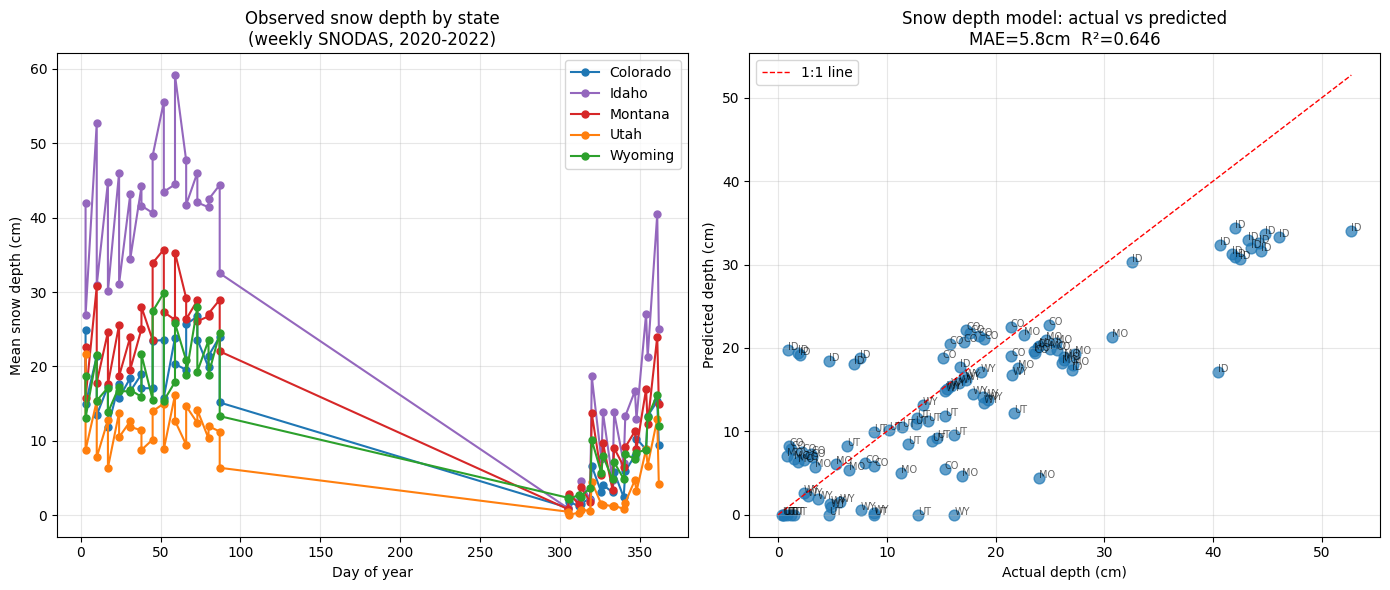

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from scipy import stats

# Get snow duration per state per water year
snow_by_wy = snow_panel.copy()
snow_by_wy['water_year'] = snow_by_wy['year'] - 1

depth_model_df = depth_panel.merge(
    snow_by_wy[['state','water_year','mean_snow_days']],
    on=['state','water_year'],
    how='left'
)

state_dummies = pd.get_dummies(depth_model_df['state'],
                                prefix='state', drop_first=True)

print(f"Merged depth model dataset: {depth_model_df.shape}")
print(f"Missing snow duration: {depth_model_df['mean_snow_days'].isna().sum()}")
print(depth_model_df[['state','date','doy',
                       'mean_snow_days','depth_cm']].head(10))


feature_df = pd.concat([
    depth_model_df[['doy','mean_snow_days']],
    state_dummies
], axis=1).dropna()

target = depth_model_df.loc[feature_df.index, 'depth_cm']

X = feature_df.values
y = target.values

wy = depth_model_df.loc[feature_df.index, 'water_year']
train_mask = wy == 2020   
test_mask  = wy == 2021   

X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

print(f"\nTrain samples: {len(X_train)}  (winter 2020-2021)")
print(f"Test samples:  {len(X_test)}   (winter 2021-2022)")

lr_depth_state = LinearRegression()
lr_depth_state.fit(X_train, y_train)

feature_names = ['doy', 'mean_snow_days'] + list(state_dummies.columns)
print("\nSnow depth model coefficients:")
for feat, coef in zip(feature_names, lr_depth_state.coef_):
    print(f"  {feat:<25} {coef:.4f}")
print(f"  {'intercept':<25} {lr_depth_state.intercept_:.4f}")

y_pred = lr_depth_state.predict(X_test)
y_pred = np.clip(y_pred, 0, None)

print(f"\nTest MAE: {mean_absolute_error(y_test, y_pred):.1f} cm")
print(f"Test R²:  {r2_score(y_test, y_pred):.3f}")

# Predict depth for future scenario
print("\nPredicted mean depth by state on Jan 15 (DOY 15):")
print(f"{'State':<12} {'Normal year':>12} {'Bad year (-10d)':>16} {'Good year (+10d)':>17}")
print("-" * 58)

state_list = ['colorado','idaho','montana','utah','wyoming']
for state in state_list:
    row_base = {'doy': 15, 'mean_snow_days': 43.0}
    for col in state_dummies.columns:
        row_base[col] = 1 if col == f'state_{state}' else 0

    row_bad  = row_base.copy()
    row_bad['mean_snow_days']  = 33.0   

    row_good = row_base.copy()
    row_good['mean_snow_days'] = 53.0   

    pred_normal = max(0, lr_depth_state.predict(
        [list(row_base.values())])[0])
    pred_bad    = max(0, lr_depth_state.predict(
        [list(row_bad.values())])[0])
    pred_good   = max(0, lr_depth_state.predict(
        [list(row_good.values())])[0])

    print(f"  {state:<12} {pred_normal:>10.1f}cm "
          f"{pred_bad:>14.1f}cm {pred_good:>15.1f}cm")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors_map = {
    'colorado':'#1f77b4', 'utah':'#ff7f0e', 'wyoming':'#2ca02c',
    'montana':'#d62728',  'idaho':'#9467bd'
}
for state in state_list:
    mask = depth_panel['state'] == state
    d    = depth_panel[mask].sort_values('doy')
    axes[0].plot(d['doy'], d['depth_cm'],
                 'o-', label=state.title(),
                 color=colors_map[state], linewidth=1.5, markersize=5)

axes[0].set_xlabel("Day of year")
axes[0].set_ylabel("Mean snow depth (cm)")
axes[0].set_title("Observed snow depth by state\n(weekly SNODAS, 2020-2022)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_test, y_pred, alpha=0.7, s=60)
axes[1].plot([0, y_test.max()], [0, y_test.max()],
             'r--', linewidth=1, label='1:1 line')
for i, (yt, yp) in enumerate(zip(y_test, y_pred)):
    state = depth_model_df[test_mask]['state'].iloc[i]
    axes[1].annotate(state[:2].upper(),
                     (yt, yp), fontsize=7, alpha=0.6)
axes[1].set_xlabel("Actual depth (cm)")
axes[1].set_ylabel("Predicted depth (cm)")
axes[1].set_title(f"Snow depth model: actual vs predicted\n"
                  f"MAE={mean_absolute_error(y_test,y_pred):.1f}cm  "
                  f"R²={r2_score(y_test,y_pred):.3f}")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(state_dir / "state_depth_model.png", dpi=150)
plt.show()

In [ ]:
# Compute annual mean depth per state 
annual_depth = depth_panel.groupby(['state','water_year'])['depth_cm'].mean().reset_index()
annual_depth.columns = ['state','year','mean_depth_cm']

annual_depth['gdp_year'] = annual_depth['year'] + 1

print("Annual mean depth per state:")
print(annual_depth.pivot(index='gdp_year', columns='state', 
                          values='mean_depth_cm').round(1))

depth_gdp = annual_depth.merge(
    panel[['state','year','outdoor_rec_gdp_millions','log_gdp']],
    left_on  = ['state','gdp_year'],
    right_on = ['state','year'],
    how='inner'
)

print(f"\nMerged depth-GDP dataset: {depth_gdp.shape}")
print(depth_gdp[['state','gdp_year','mean_depth_cm',
                  'outdoor_rec_gdp_millions']].to_string(index=False))

Annual mean depth per state:
state     colorado  idaho  montana  utah  wyoming
gdp_year                                         
2021          13.9   30.2     19.1   7.4     15.9
2022          13.9   30.4     18.3   9.2     12.9

Merged depth-GDP dataset: (10, 7)
   state  gdp_year  mean_depth_cm  outdoor_rec_gdp_millions
colorado      2021      13.908814                   988.257
colorado      2022      13.930360                  1433.813
   idaho      2021      30.161432                    87.555
   idaho      2022      30.384998                   122.267
 montana      2021      19.113353                    53.564
 montana      2022      18.315532                    75.386
    utah      2021       7.404511                   392.232
    utah      2022       9.158723                   540.187
 wyoming      2021      15.861967                    33.318
 wyoming      2022      12.866086                    42.986


In [ ]:
import urllib.request
from datetime import date, timedelta

snodas_base = Path("/Users/evabenson/Files/thesis/snow_ml/gee/snodas")

sample_dates = []
for start_year in range(2012, 2020):
    d_start = date(start_year, 11, 1)
    d_end   = date(start_year + 1, 3, 31)
    d = d_start
    while d <= d_end:
        sample_dates.append(d)
        d += timedelta(days=7)

print(f"Total dates to download: {len(sample_dates)}")
print(f"Date range: {sample_dates[0]} to {sample_dates[-1]}")

def download_snodas(target_date):
    yyyy  = target_date.strftime("%Y")
    mm    = target_date.strftime("%m")
    mon   = target_date.strftime("%b")
    mmm   = f"{mm}_{mon}"
    ddstr = target_date.strftime("%Y%m%d")
    tar_name  = f"SNODAS_{ddstr}.tar"
    local_tar = snodas_base / tar_name

    if local_tar.exists():
        return True

    url = (f"https://noaadata.apps.nsidc.org/NOAA/G02158/masked/"
           f"{yyyy}/{mmm}/{tar_name}")
    try:
        print(f"  Downloading {ddstr}...", end=" ")
        urllib.request.urlretrieve(url, local_tar)
        print("done")
        return True
    except Exception as e:
        print(f"FAILED: {e}")
        return False

for d in sample_dates:
    download_snodas(d)

print(f"\nTotal SNODAS files now: {len(list(snodas_base.glob('*.tar')))}")

Total dates to download: 176
Date range: 2012-11-01 to 2020-03-27

Total SNODAS files now: 219


In [ ]:
tar_files = sorted(snodas_base.glob("SNODAS_*.tar"))
print(f"Total SNODAS files: {len(tar_files)}")
print(f"Date range: {tar_files[0].name} to {tar_files[-1].name}")

# Rebuild depth panel w/ SNODAS files
records = []

for tar_path in tar_files:
    datestr = tar_path.stem.replace("SNODAS_", "")
    d       = date(int(datestr[:4]), int(datestr[4:6]), int(datestr[6:8]))
    doy     = d.timetuple().tm_yday
    wy      = get_water_year(d)

    for state in STATE_BOUNDS:
        mean_depth = get_state_mean_depth(tar_path, state)
        records.append({
            'date':       str(d),
            'year':       d.year,
            'doy':        doy,
            'water_year': wy,
            'state':      state,
            'depth_cm':   mean_depth
        })

    print(f"  {d}: done")

depth_panel_full = pd.DataFrame(records)
print(f"\nFull depth panel shape: {depth_panel_full.shape}")

# Annual mean depth per state per water year
annual_depth_full = depth_panel_full.groupby(
    ['state','water_year'])['depth_cm'].mean().reset_index()
annual_depth_full.columns = ['state','year','mean_depth_cm']
annual_depth_full['gdp_year'] = annual_depth_full['year'] + 1

print("\nAnnual mean depth per state (cm):")
print(annual_depth_full.pivot(index='gdp_year', columns='state',
                               values='mean_depth_cm').round(1))

depth_gdp_full = annual_depth_full.merge(
    panel[['state','year','outdoor_rec_gdp_millions','log_gdp']],
    left_on  = ['state','gdp_year'],
    right_on = ['state','year'],
    how='inner'
)

print(f"\nMerged depth-GDP dataset: {depth_gdp_full.shape}")
print(f"Years covered: {depth_gdp_full['gdp_year'].min()} - "
      f"{depth_gdp_full['gdp_year'].max()}")
print(f"Observations per state: {depth_gdp_full.groupby('state').size().to_dict()}")

Total SNODAS files: 219
Date range: SNODAS_20121101.tar to SNODAS_20220328.tar
  2012-11-01: done
  2012-11-08: done
  2012-11-15: done
  2012-11-22: done
  2012-11-29: done
  2012-12-06: done
  2012-12-13: done
  2012-12-27: done
  2013-01-03: done
  2013-01-10: done
  2013-01-17: done
  2013-01-24: done
  2013-01-31: done
  2013-02-07: done
  2013-02-14: done
  2013-02-21: done
  2013-02-28: done
  2013-03-07: done
  2013-03-14: done
  2013-03-21: done
  2013-03-28: done
  2013-11-01: done
  2013-11-08: done
  2013-11-15: done
  2013-11-22: done
  2013-11-29: done
  2013-12-06: done
  2013-12-13: done
  2013-12-20: done
  2013-12-27: done
  2014-01-03: done
  2014-01-10: done
  2014-01-17: done
  2014-01-24: done
  2014-01-31: done
  2014-02-07: done
  2014-02-14: done
  2014-02-21: done
  2014-02-28: done
  2014-03-07: done
  2014-03-14: done
  2014-03-21: done
  2014-03-28: done
  2014-11-01: done
  2014-11-08: done
  2014-11-15: done
  2014-11-22: done
  2014-11-29: done
  2014-12

SNOW DEPTH --> OUTDOOR RECREATION GDP

  β (depth cm):   -0.0171
  R²:             0.108
  p-value:        0.020
  Std error:      0.0071

  Interpret: +1cm snow depth → -1.71% change in outdoor rec GDP
  Mean GDP per state: $327.3M
  +1cm depth → $-5.6M per state
  +1cm depth → $-28.0M across 5 states

Scenario                               Per state     5 states
------------------------------------------------------------
  Average year (baseline)           $     -0.0M $     -0.0M
  Good year (+5cm deeper)           $    -28.0M $   -140.0M
  Great year (+10cm deeper)         $    -56.0M $   -280.0M
  Poor year (-5cm shallower)        $    +28.0M $   +140.0M
  Bad year (-10cm shallower)        $    +56.0M $   +280.0M


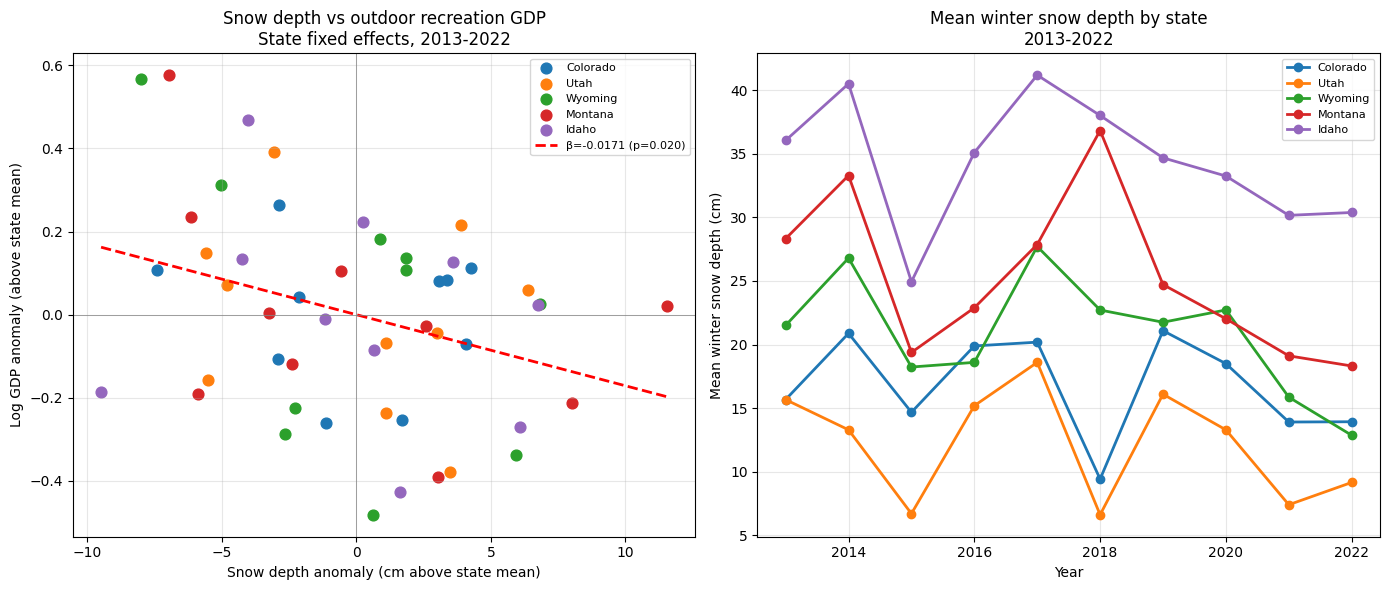

In [24]:
from scipy import stats

# State FE
depth_gdp_full['depth_demeaned'] = depth_gdp_full.groupby('state')['mean_depth_cm'].transform(
    lambda x: x - x.mean()
)
depth_gdp_full['gdp_demeaned'] = depth_gdp_full.groupby('state')['log_gdp'].transform(
    lambda x: x - x.mean()
)

# Regression: snow depth --> outdoor gdp
X = depth_gdp_full['depth_demeaned'].values
y = depth_gdp_full['gdp_demeaned'].values

slope, intercept, r, p, se = stats.linregress(X, y)

mean_gdp = depth_gdp_full['outdoor_rec_gdp_millions'].mean()

print("SNOW DEPTH --> OUTDOOR RECREATION GDP")
print(f"\n  β (depth cm):   {slope:.4f}")
print(f"  R²:             {r**2:.3f}")
print(f"  p-value:        {p:.3f}")
print(f"  Std error:      {se:.4f}")
print(f"\n  Interpret: +1cm snow depth → {slope*100:.2f}% change in outdoor rec GDP")
print(f"  Mean GDP per state: ${mean_gdp:.1f}M")
print(f"  +1cm depth → ${slope*mean_gdp:.1f}M per state")
print(f"  +1cm depth → ${slope*mean_gdp*5:.1f}M across 5 states")

print(f"\n{'Scenario':<35} {'Per state':>12} {'5 states':>12}")
print("-" * 60)

scenarios = [
    ("Average year (baseline)",        0),
    ("Good year (+5cm deeper)",        5),
    ("Great year (+10cm deeper)",     10),
    ("Poor year (-5cm shallower)",    -5),
    ("Bad year (-10cm shallower)",   -10),
]

for label, delta in scenarios:
    per_state = slope * delta * mean_gdp
    total     = per_state * 5
    print(f"  {label:<33} ${per_state:>+9.1f}M ${total:>+9.1f}M")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors_map = {
    'colorado':'#1f77b4', 'utah':'#ff7f0e', 'wyoming':'#2ca02c',
    'montana':'#d62728',  'idaho':'#9467bd'
}

for state in ['colorado','utah','wyoming','montana','idaho']:
    mask = depth_gdp_full['state'] == state
    axes[0].scatter(depth_gdp_full[mask]['depth_demeaned'],
                    depth_gdp_full[mask]['gdp_demeaned'],
                    label=state.title(), color=colors_map[state], s=60)

x_line = np.linspace(X.min(), X.max(), 100)
axes[0].plot(x_line, slope*x_line + intercept,
             'r--', linewidth=2, label=f'β={slope:.4f} (p={p:.3f})')
axes[0].axhline(0, color='gray', linewidth=0.5)
axes[0].axvline(0, color='gray', linewidth=0.5)
axes[0].set_xlabel("Snow depth anomaly (cm above state mean)")
axes[0].set_ylabel("Log GDP anomaly (above state mean)")
axes[0].set_title("Snow depth vs outdoor recreation GDP\nState fixed effects, 2013-2022")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

for state in ['colorado','utah','wyoming','montana','idaho']:
    mask = depth_gdp_full['state'] == state
    d    = depth_gdp_full[mask].sort_values('gdp_year')
    axes[1].plot(d['gdp_year'], d['mean_depth_cm'],
                 'o-', label=state.title(),
                 color=colors_map[state], linewidth=2, markersize=6)

axes[1].set_xlabel("Year")
axes[1].set_ylabel("Mean winter snow depth (cm)")
axes[1].set_title("Mean winter snow depth by state\n2013-2022")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(state_dir / "depth_gdp_regression.png", dpi=150)
plt.show()

SNOW DEPTH --> GDP (controlling for time trend)
State FE + year trend, excluding 2020

  β (snow depth):  0.0015
  β (time trend):  0.0782
  R²:              0.792
  p-value (depth): 0.680

  Interpret: +1cm snow depth → 0.15% GDP change
  +1cm depth → $0.5M per state
  +1cm depth → $2.5M across 5 states


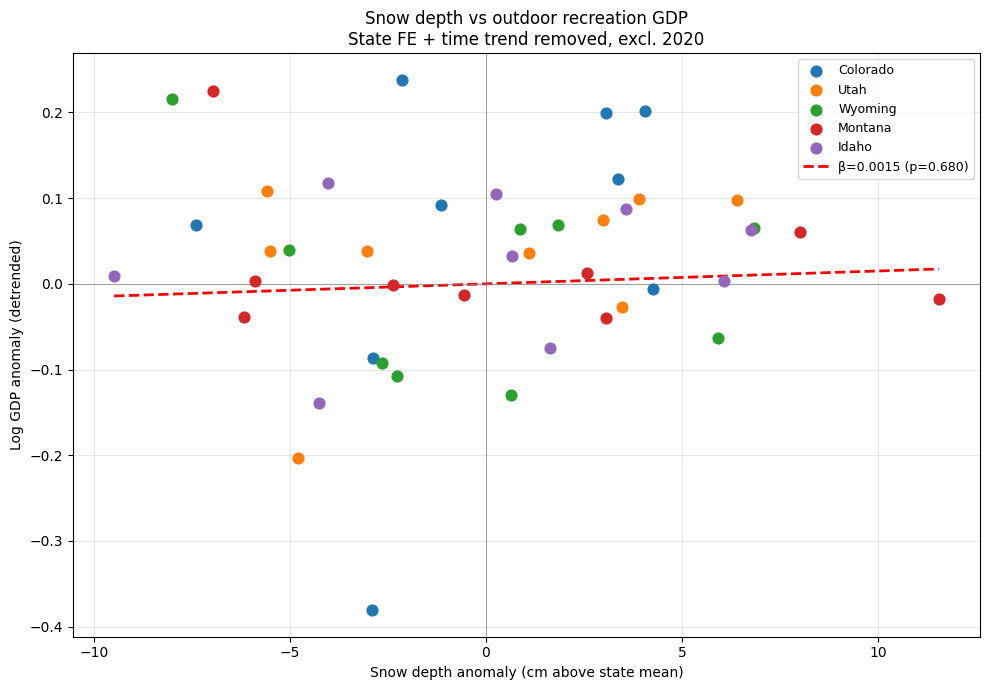

In [25]:
# Add year trend to control for GDP growth

depth_gdp_full['year_centered'] = depth_gdp_full['gdp_year'] - 2017

# State FE
depth_gdp_full['depth_demeaned'] = depth_gdp_full.groupby('state')['mean_depth_cm'].transform(
    lambda x: x - x.mean()
)
depth_gdp_full['gdp_demeaned'] = depth_gdp_full.groupby('state')['log_gdp'].transform(
    lambda x: x - x.mean()
)

depth_gdp_full['year_demeaned'] = depth_gdp_full.groupby('state')['year_centered'].transform(
    lambda x: x - x.mean()
)

# Regression with time trend controlled 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Remove 2020 COVID outlier
mask = depth_gdp_full['gdp_year'] != 2020

X_full = np.column_stack([
    depth_gdp_full[mask]['depth_demeaned'].values,
    depth_gdp_full[mask]['year_demeaned'].values
])
y_full = depth_gdp_full[mask]['gdp_demeaned'].values

lr_trend = LinearRegression().fit(X_full, y_full)

print("SNOW DEPTH --> GDP (controlling for time trend)")
print("State FE + year trend, excluding 2020")
print(f"\n  β (snow depth):  {lr_trend.coef_[0]:.4f}")
print(f"  β (time trend):  {lr_trend.coef_[1]:.4f}")
print(f"  R²:              {r2_score(y_full, lr_trend.predict(X_full)):.3f}")

# Statistical significance via scipy
from scipy import stats
slope_d, _, r_d, p_d, se_d = stats.linregress(
    depth_gdp_full[mask]['depth_demeaned'].values,
    y_full - lr_trend.coef_[1] * depth_gdp_full[mask]['year_demeaned'].values
)

print(f"  p-value (depth): {p_d:.3f}")
print(f"\n  Interpret: +1cm snow depth → {lr_trend.coef_[0]*100:.2f}% GDP change")

mean_gdp = depth_gdp_full['outdoor_rec_gdp_millions'].mean()
dollar   = lr_trend.coef_[0] * mean_gdp
print(f"  +1cm depth → ${dollar:.1f}M per state")
print(f"  +1cm depth → ${dollar*5:.1f}M across 5 states")

y_detrended = (y_full - 
               lr_trend.coef_[1] * depth_gdp_full[mask]['year_demeaned'].values)
X_depth     = depth_gdp_full[mask]['depth_demeaned'].values

fig, ax = plt.subplots(figsize=(10, 7))

for state in ['colorado','utah','wyoming','montana','idaho']:
    smask = depth_gdp_full[mask]['state'] == state
    ax.scatter(X_depth[smask], y_detrended[smask],
               label=state.title(), color=colors_map[state], s=60, zorder=3)

x_line = np.linspace(X_depth.min(), X_depth.max(), 100)
ax.plot(x_line, slope_d*x_line,
        'r--', linewidth=2,
        label=f'β={slope_d:.4f} (p={p_d:.3f})')
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlabel("Snow depth anomaly (cm above state mean)")
ax.set_ylabel("Log GDP anomaly (detrended)")
ax.set_title("Snow depth vs outdoor recreation GDP\n"
             "State FE + time trend removed, excl. 2020")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(state_dir / "depth_gdp_detrended.png", dpi=150)
plt.show()